In [1]:
# ProoV: VW & Audi Used Car Price Prediction
# Volkswagen, Audi, VW, Golf, A4 are trademarks of Volkswagen AG.
# Independent educational case study. Not affiliated with VW AG.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False
})

sns.set_palette('muted')

print('Libraries loaded successfully.')

# --- PROOV HELPER (Do not modify) ---
import IPython.display

def proov_tick(task_id):
    IPython.display.display(
        IPython.display.Javascript(
            f'window.parent.postMessage({{ type: "PROOV_CHECKPOINT", checkpoint: "{task_id}" }}, "*");'
        )
    )

proov_tick('setup_complete')

Libraries loaded successfully.


<IPython.core.display.Javascript object>

In [2]:
import pandas as pd

print("Loading datasets from local files...")

vw = pd.read_csv("vw.csv")
audi = pd.read_csv("audi.csv")

print(f"✓ Loaded vw.csv: {len(vw):,} rows")
print(f"✓ Loaded audi.csv: {len(audi):,} rows")

print(f"\nTotal: {len(vw) + len(audi):,} listings ready for analysis.")

Loading datasets from local files...
✓ Loaded vw.csv: 15,157 rows
✓ Loaded audi.csv: 10,668 rows

Total: 25,825 listings ready for analysis.


In [3]:
# Quick sanity check
print('=== VW Dataset ===')
print(f'Shape: {vw.shape}')
display(vw.head(3))

print('\n=== Audi Dataset ===')
print(f'Shape: {audi.shape}')
display(audi.head(3))

=== VW Dataset ===
Shape: (15157, 9)


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,T-Roc,2019,25000,Automatic,13904,Diesel,145,49.6,2.0
1,T-Roc,2019,26883,Automatic,4562,Diesel,145,49.6,2.0
2,T-Roc,2019,20000,Manual,7414,Diesel,145,50.4,2.0



=== Audi Dataset ===
Shape: (10668, 9)


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4


In [4]:
df = pd.concat([vw.assign(brand='VW'), audi.assign(brand='Audi')], ignore_index=True)
print('Sprint 1 Prep: df is ready with VW and Audi combined.')

Sprint 1 Prep: df is ready with VW and Audi combined.


In [5]:
# PREP: Re-run Sprint 2 feature engineering so Sprint 3 models work

df = df[(df['engineSize'] > 0) &
        (df['price'] >= 500) &
        (df['price'] <= 100000)].copy()

df['car_age'] = 2020 - df['year']

df['mileage_per_year'] = df['mileage'] / df['car_age']

df['mileage_per_year'] = df['mileage_per_year'].replace(
    [np.inf, -np.inf, np.nan],
    0
)

y = df['price']

X = df.drop(columns=['model', 'year', 'price'])

X = pd.get_dummies(
    X,
    columns=['transmission', 'fuelType', 'brand'],
    drop_first=True
)

print('Sprint 2 Prep: X and y are ready for modeling.')

print('X shape:', X.shape)
print('y shape:', y.shape)

Sprint 2 Prep: X and y are ready for modeling.
X shape: (25735, 12)
y shape: (25735,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f'Training set:  {X_train.shape[0]:,} rows')
print(f'Test set:      {X_test.shape[0]:,} rows')

proov_tick('task_3_1')

Training set:  20,588 rows
Test set:      5,147 rows


<IPython.core.display.Javascript object>

In [7]:
lr = LinearRegression()

# Fit model
lr.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)

def evaluate(name, y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f'\n{name}')
    print(f'  R2   = {r2:.4f}  ({r2*100:.1f}% of variance explained)')
    print(f'  MAE  = £{mae:,.0f}')
    print(f'  RMSE = £{rmse:,.0f}')
    return {'R2': round(r2,4), 'MAE': round(mae,0), 'RMSE': round(rmse,0)}

lr_results = evaluate('Linear Regression', y_test, y_pred_lr)

proov_tick('task_3_2')


Linear Regression
  R2   = 0.8328  (83.3% of variance explained)
  MAE  = £2,622
  RMSE = £4,070


<IPython.core.display.Javascript object>

In [8]:
print('Training Random Forest... (may take ~60 seconds)')

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Fit model
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

rf_results = evaluate(
    'Random Forest',
    y_test,
    y_pred_rf
)

proov_tick('task_3_3')

Training Random Forest... (may take ~60 seconds)

Random Forest
  R2   = 0.9504  (95.0% of variance explained)
  MAE  = £1,438
  RMSE = £2,218


<IPython.core.display.Javascript object>

In [10]:
comparison = pd.DataFrame({
    'Model':   ['Linear Regression', 'Random Forest'],
    'R2':      [lr_results['R2'],  rf_results['R2']],
    'MAE (£)': [lr_results['MAE'], rf_results['MAE']],
    'RMSE (£)':[lr_results['RMSE'],rf_results['RMSE']],
})

display(comparison.style
    .highlight_max(subset=['R2'], color='#475b4e')
    .highlight_min(subset=['MAE (£)','RMSE (£)'], color="#475b4e")
    .format({'R2':'{:.4f}','MAE (£)':'£{:,.0f}','RMSE (£)':'£{:,.0f}'}))

proov_tick('task_3_4')

,Model,R2,MAE (£),RMSE (£)
0,Linear Regression,0.8328,"£2,622","£4,070"
1,Random Forest,0.9504,"£1,438","£2,218"


<IPython.core.display.Javascript object>

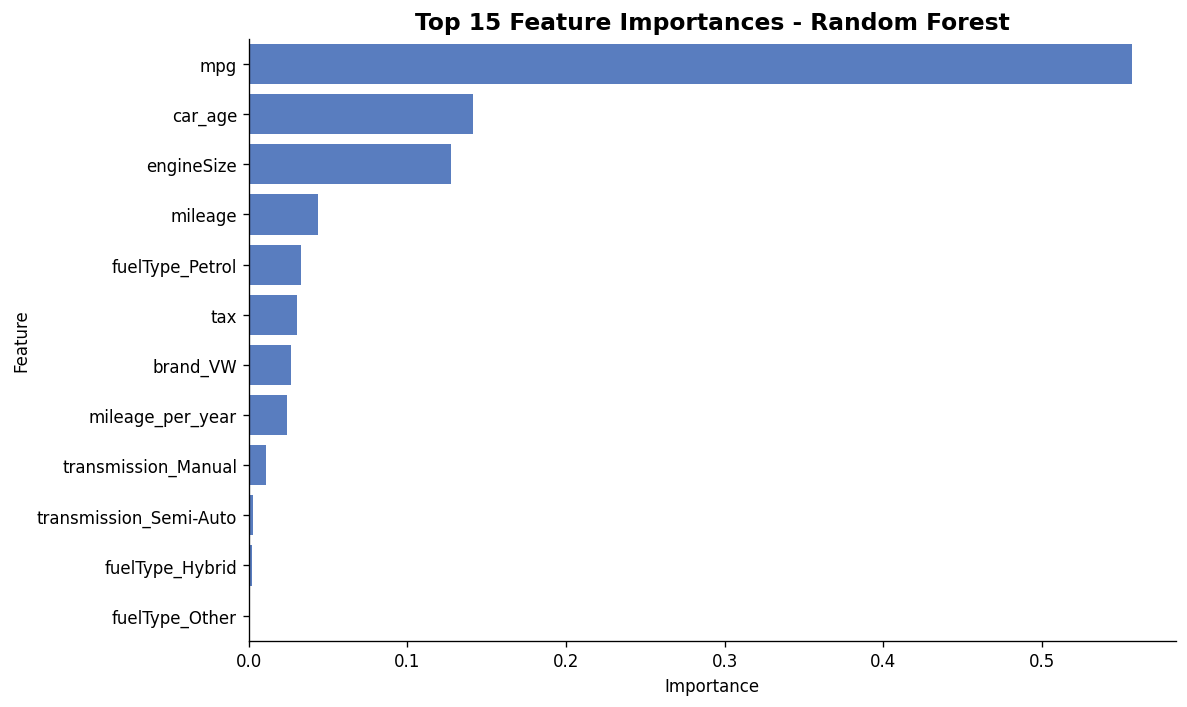

<IPython.core.display.Javascript object>

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

# Feature importances
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

# Top 15 features
top15 = importance_df.sort_values(
    'Importance',
    ascending=False
).head(15)

# Plot
sns.barplot(
    data=top15,
    x='Importance',
    y='Feature',
    ax=ax
)

ax.set_title(
    'Top 15 Feature Importances - Random Forest',
    fontsize=14,
    fontweight='bold'
)
ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

proov_tick('task_3_5')

In [12]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

print("Running Grid Search...")
grid.fit(X_train, y_train)

print("\nBest Parameters:")
print(grid.best_params_)

print("\nBest CV R²:")
print(f"{grid.best_score_:.4f}")

best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_test)

best_results = evaluate(
    'Tuned Random Forest',
    y_test,
    y_pred_best
)

proov_tick('stretch_goal')

Running Grid Search...

Best Parameters:
{'max_depth': 20, 'n_estimators': 200}

Best CV R²:
0.9412

Tuned Random Forest
  R2   = 0.9516  (95.2% of variance explained)
  MAE  = £1,421
  RMSE = £2,190


<IPython.core.display.Javascript object>

In [13]:
# Create empty rows with same columns as X
car_a = pd.DataFrame(0, index=[0], columns=X.columns)
car_b = pd.DataFrame(0, index=[0], columns=X.columns)

# Common features
for car in [car_a, car_b]:
    car['mileage'] = 30000
    car['car_age'] = 2          # 2020 - 2018
    car['mileage_per_year'] = 15000

# Car A: 2018 VW Golf, 1.4L, Manual, Petrol
car_a['engineSize'] = 1.4

if 'fuelType_Petrol' in X.columns:
    car_a['fuelType_Petrol'] = 1

if 'brand_VW' in X.columns:
    car_a['brand_VW'] = 1

# Manual is usually the dropped baseline category,
# so leave transmission columns as 0 unless your encoding differs.

# Car B: 2018 Audi A4, 2.0L, Automatic, Petrol
car_b['engineSize'] = 2.0

if 'fuelType_Petrol' in X.columns:
    car_b['fuelType_Petrol'] = 1

if 'transmission_Automatic' in X.columns:
    car_b['transmission_Automatic'] = 1

# Audi is usually the baseline because brand_VW was created,
# so leave brand columns at 0.

# Predictions
golf_price = rf.predict(car_a)[0]
a4_price = rf.predict(car_b)[0]

print(f"Predicted price - VW Golf: £{golf_price:,.0f}")
print(f"Predicted price - Audi A4: £{a4_price:,.0f}")

proov_tick('task_4_1')

Predicted price - VW Golf: £21,481
Predicted price - Audi A4: £29,402


<IPython.core.display.Javascript object>